# Migration Network Analysis

Goal:
- Which countries are migration hubs?
- Which countries are transit hubs?
- What does the global migration network look like?

In [1]:
# 01 Check venv
import sys
print(sys.executable)

/Users/andreasgilling/Documents/GitHub/german-migration-analysis/venv/bin/python


In [2]:
%pip install networkx


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# 02 Config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

plt.style.use("default")
sns.set_style("whitegrid")

In [4]:
# 03 Load network dataset
df_network = pd.read_csv("../data/processed/migration_network_flows.csv")

df_network.head()

,year,origin,destination,migrants
0,2000,Afghanistan,Germany,13.0
1,2000,Albanien,Germany,45.0
2,2000,Algerien,Germany,64.0
3,2000,Andorra,Germany,12.0
4,2000,Angola,Germany,17.0


In [5]:
df_network.shape

(5848, 4)

In [6]:
df_network.info()

<class 'pandas.DataFrame'>
RangeIndex: 5848 entries, 0 to 5847
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         5848 non-null   int64  
 1   origin       5848 non-null   str    
 2   destination  5848 non-null   str    
 3   migrants     5848 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 182.9 KB


In [7]:
df_network.describe()

,year,migrants
count,5848.000000,5848.000000
mean,2011.998974,1442.204856
std,7.213877,6760.673901
min,2000.000000,0.000000
25%,2006.000000,78.000000
50%,2012.000000,260.000000
75%,2018.000000,804.000000
max,2024.000000,150679.000000


In [8]:
# unique countries
origins = df_network["origin"].unique()
destinations = df_network["destination"].unique()

countries = set(origins).union(set(destinations))

print("Number of countries:", len(countries))
print("Years:", df_network["year"].min(), "-", df_network["year"].max())

Number of countries: 120
Years: 2000 - 2024


In [9]:
# total migration flows
total_flows = df_network["migrants"].sum()
print("Total migrants in dataset:", total_flows)

Total migrants in dataset: 8434014.0


In [10]:
# create directed graph
G = nx.DiGraph()

# add edges
for _, row in df_network.iterrows():
    G.add_edge(
        row["origin"],
        row["destination"],
        weight=row["migrants"]
    )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 120
Edges: 238


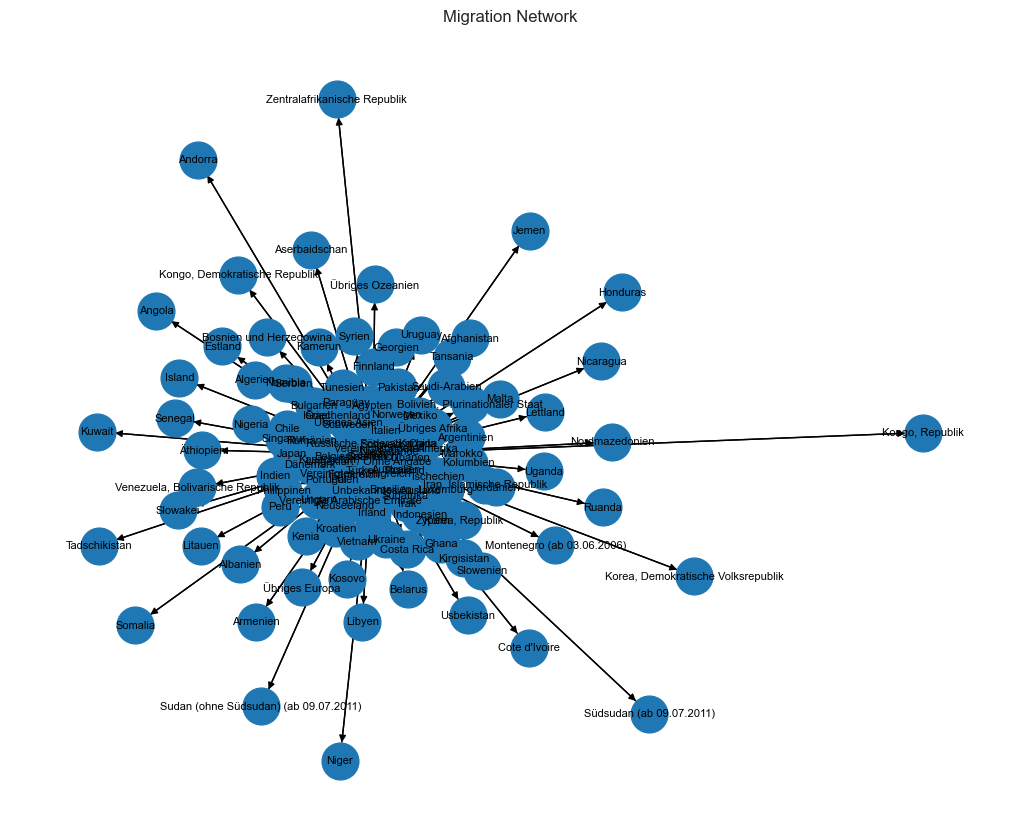

In [11]:
# Basic Network Visualization
plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=700,
    font_size=8
)
plt.title("Migration Network")
plt.show()

In [12]:
# Degree Centrality
degree_centrality = nx.degree_centrality(G)
df_degree = pd.DataFrame.from_dict(
    degree_centrality,
    orient="index",
    columns=["degree_centrality"]
)
df_degree.sort_values(
    "degree_centrality",
    ascending=False
).head(10)

,degree_centrality
Germany,2.000000
Afghanistan,0.016807
Syrien,0.016807
Spanien,0.016807
Somalia,0.016807
Slowenien,0.016807
Slowakei,0.016807
Singapur,0.016807
Serbien,0.016807
Senegal,0.016807


In [14]:
# Betweenness Centrality
betweenness = nx.betweenness_centrality(G)

df_between = pd.DataFrame.from_dict(
    betweenness,
    orient="index",
    columns=["betweenness"]
)

df_between.sort_values(
    "betweenness",
    ascending=False
).head(10)

,betweenness
Germany,1.0
Afghanistan,0.0
Syrien,0.0
Spanien,0.0
Somalia,0.0
Slowenien,0.0
Slowakei,0.0
Singapur,0.0
Serbien,0.0
Senegal,0.0


In [15]:
# Strongest Migration Flows
top_flows = df_network.sort_values(
    "migrants",
    ascending=False
).head(10)

top_flows

,year,origin,destination,migrants
3867,2016,Germany,Ungeklärt / Ohne Angabe,150679.0
4569,2019,Germany,Ungeklärt / Ohne Angabe,145345.0
4335,2018,Germany,Ungeklärt / Ohne Angabe,136167.0
4101,2017,Germany,Ungeklärt / Ohne Angabe,131545.0
5033,2021,Germany,Ungeklärt / Ohne Angabe,129084.0
5735,2024,Germany,Ungeklärt / Ohne Angabe,128593.0
5500,2023,Germany,Ungeklärt / Ohne Angabe,125684.0
4801,2020,Germany,Ungeklärt / Ohne Angabe,124472.0
5267,2022,Germany,Ungeklärt / Ohne Angabe,124404.0
4662,2019,Ungeklärt / Ohne Angabe,Germany,99875.0


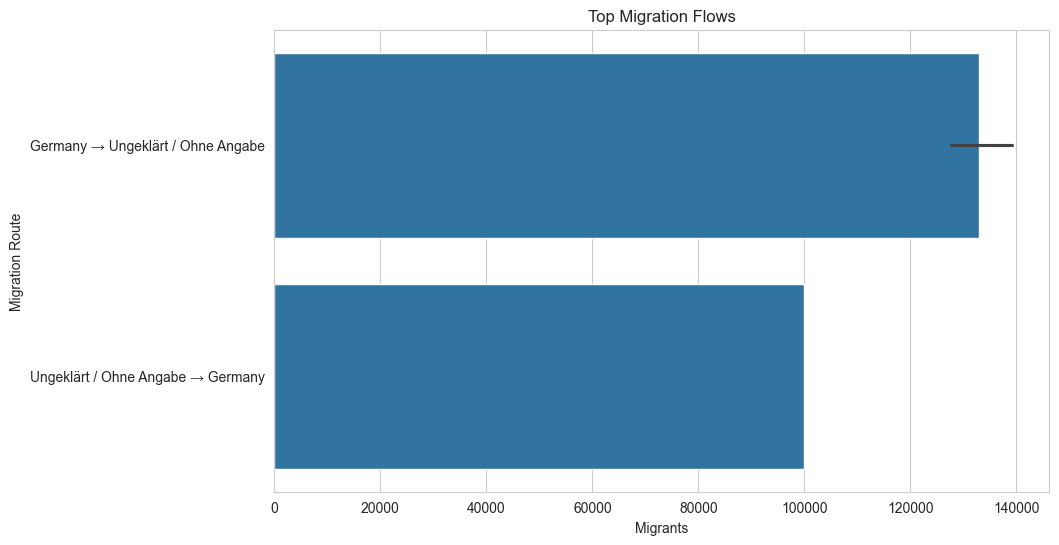

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_flows,
    x="migrants",
    y=top_flows["origin"] + " → " + top_flows["destination"]
)

plt.title("Top Migration Flows")
plt.xlabel("Migrants")
plt.ylabel("Migration Route")

plt.show()